In [ ]:
# Run 2 is a more direct replication of the authors' methods

In [2]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
import scvelo as scv
import scipy as sp
from pyannotables import tables

In [3]:
#from sctoolkit.utils import bin_pval, run_spring, sort_by_correlation, dotplot_spring
#from sctoolkit.proportions import plot_proportion_barplot, merge_ggplots
from harmony import harmonize

In [4]:
t = tables()
t = t['homo_sapiens-GRCh38-ensembl84'][['gene_name', 'gene_biotype']]
t = t[t.gene_biotype == 'protein_coding'].drop_duplicates(ignore_index=True).set_index('gene_name')

In [5]:
%config InlineBackend.figure_format = 'retina'

In [6]:
sc.set_figure_params(dpi=100)

In [7]:
adata = sc.read_h5ad("sobj_kc_clean.h5ad")
adata.var = adata.var.join(t, how='left')

In [8]:
kera = adata[adata.obs['subset_group'].isin(['KC 5', 'cKC'])].copy()

In [9]:
kera

AnnData object with n_obs × n_vars = 798 × 21819
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'X10x_cell_calling', 'G2M_score', 'S_score', 'barcode_rank', 'chemistry_10x', 'disease_status', 'empty_drops_FDR', 'ind_id', 'lesional', 'log10_n_genes', 'log10_n_umis', 'mito_cutoff_', 'mt_frac', 'n_counts', 'n_genes', 'n_umis', 'neg_log10_empty_drops_FDR', 'phase', 'predicted_cell_types', 'sample_name', 'scrublet', 'scrublet_score', 'sex', 'disease_lesional', 'batch', 'leiden', 'Cell.type', 'Cell.type.granular', 'ind_sample', 'channel', 'barcode', 'subject_id', 'global_disease_assessment', 'ad_family_history', 'sex_clinical', 'ethnicity_race', 'smoking', 'asthma', 'other_condition', 'systemic_corticosteroids', 'topical_corticosteroids', 'dupilumab', 'dupilumab_indication', 'dupilumab_other_indication', 'location', 'side', 'Disease.score..MADAD.Immune.', 'Disease.score..MADAD.Full.', 'Disease.score..MADAD.Union.', 'Cell.type.new.cornified', 'ind_disease_lesional', 'Cell.states.with.Pa

In [65]:
# mirroring the authors
sc.pp.highly_variable_genes(kera, n_top_genes=500)
sc.pp.pca(kera, 50)
kera.obsm['X_harmony'] = harmonize(kera.obsm['X_pca'], kera.obs, 'ind_id')
sc.pp.neighbors(kera, use_rep='X_harmony', n_neighbors=150) 
#sc.pp.neighbors(kera, n_neighbors=150) # this mirrors the authors umap result better, but there are ind_id batch effects present
sc.tl.umap(kera)

	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
	Completed 4 / 10 iteration(s).
	Completed 5 / 10 iteration(s).
	Completed 6 / 10 iteration(s).
	Completed 7 / 10 iteration(s).
	Completed 8 / 10 iteration(s).
	Completed 9 / 10 iteration(s).
	Completed 10 / 10 iteration(s).


In [66]:
sc.tl.leiden(kera, resolution=1.)

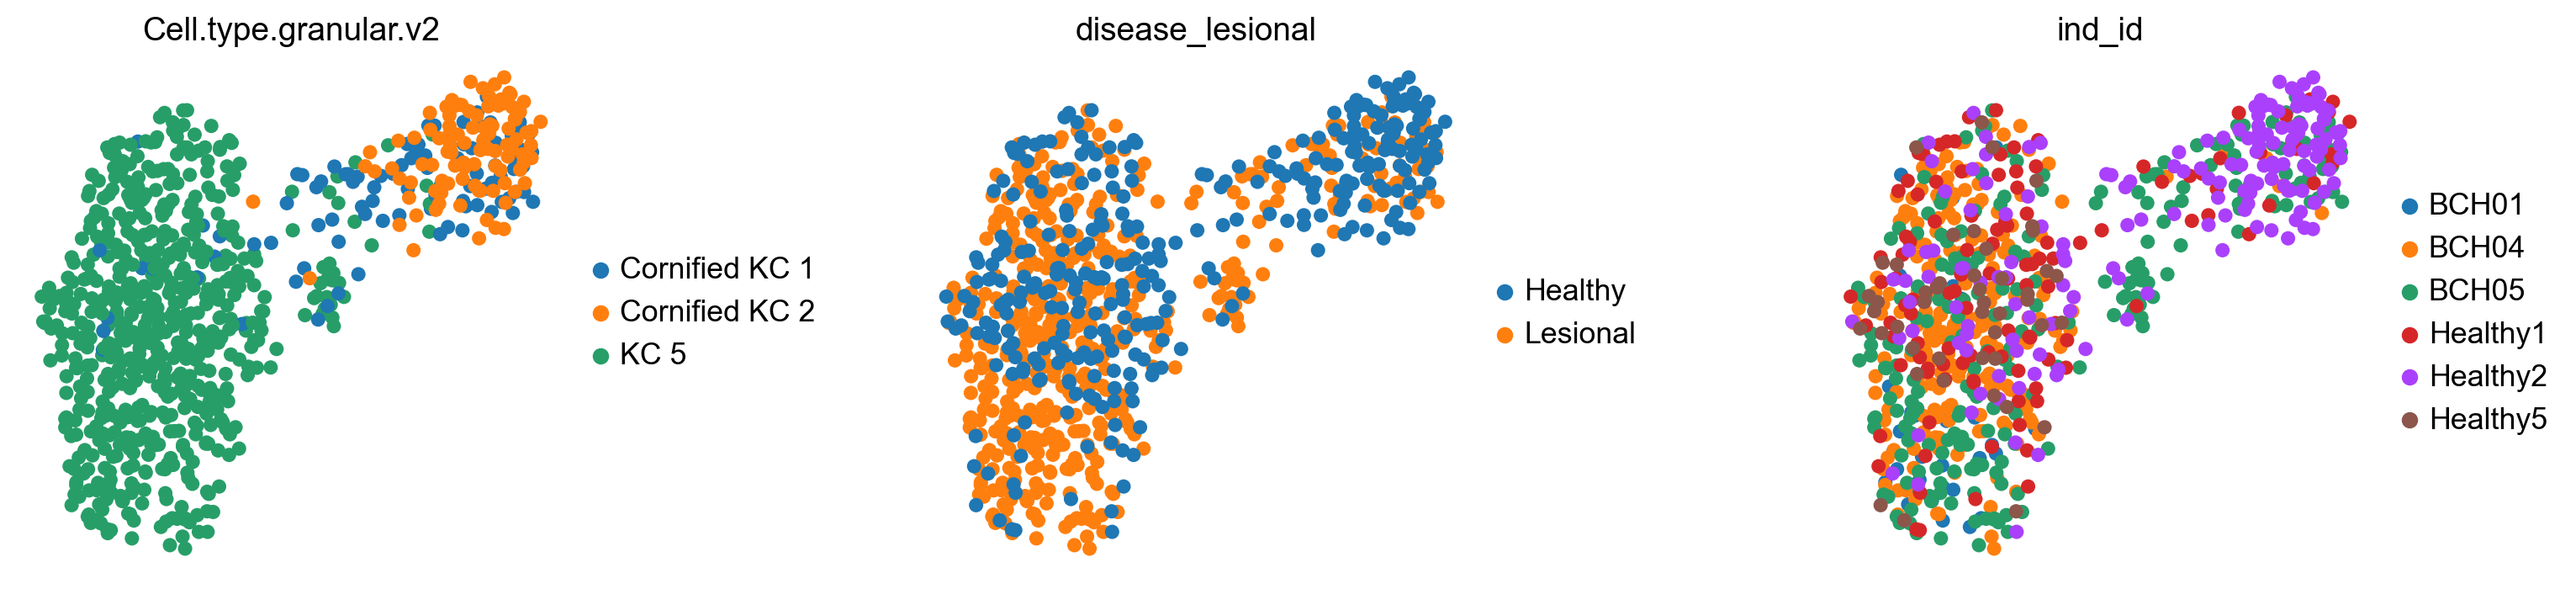

In [67]:
sc.pl.umap(kera, color=['Cell.type.granular.v2', 'disease_lesional', 'ind_id'], wspace=0.5, frameon=False)

### Authors' run for reference: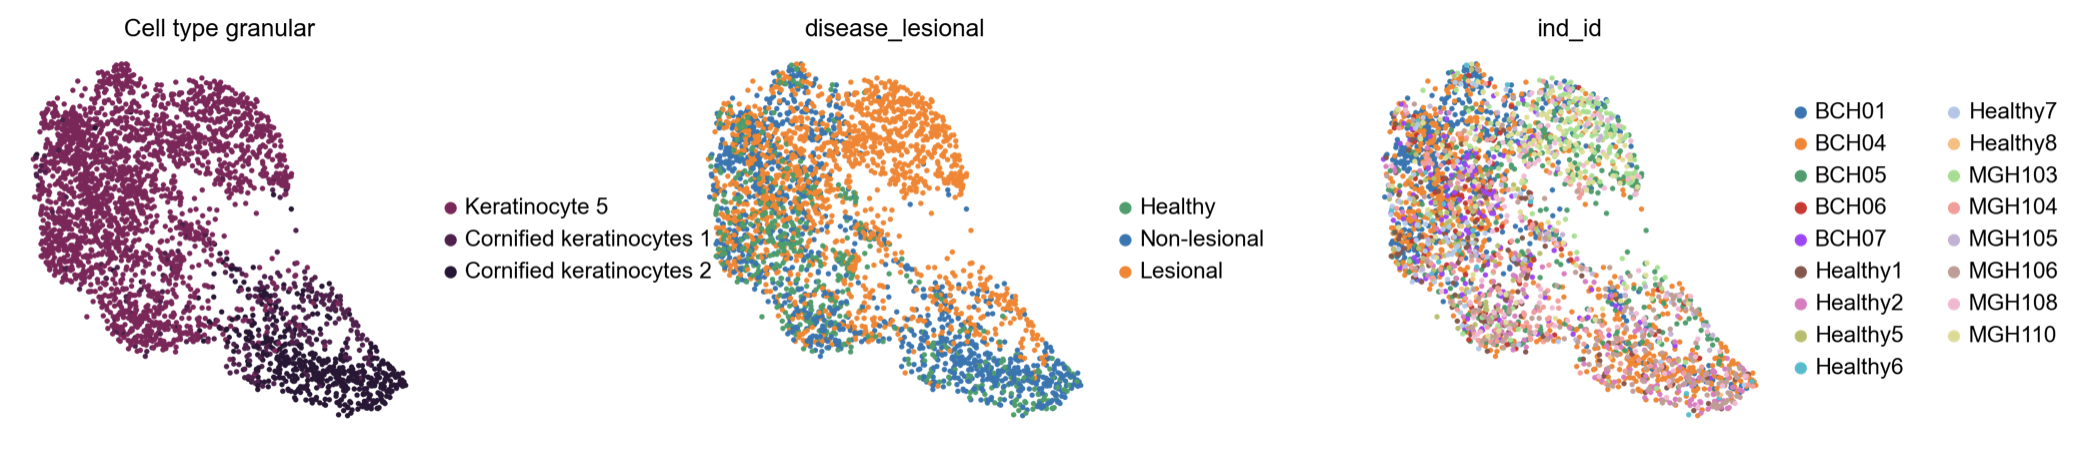


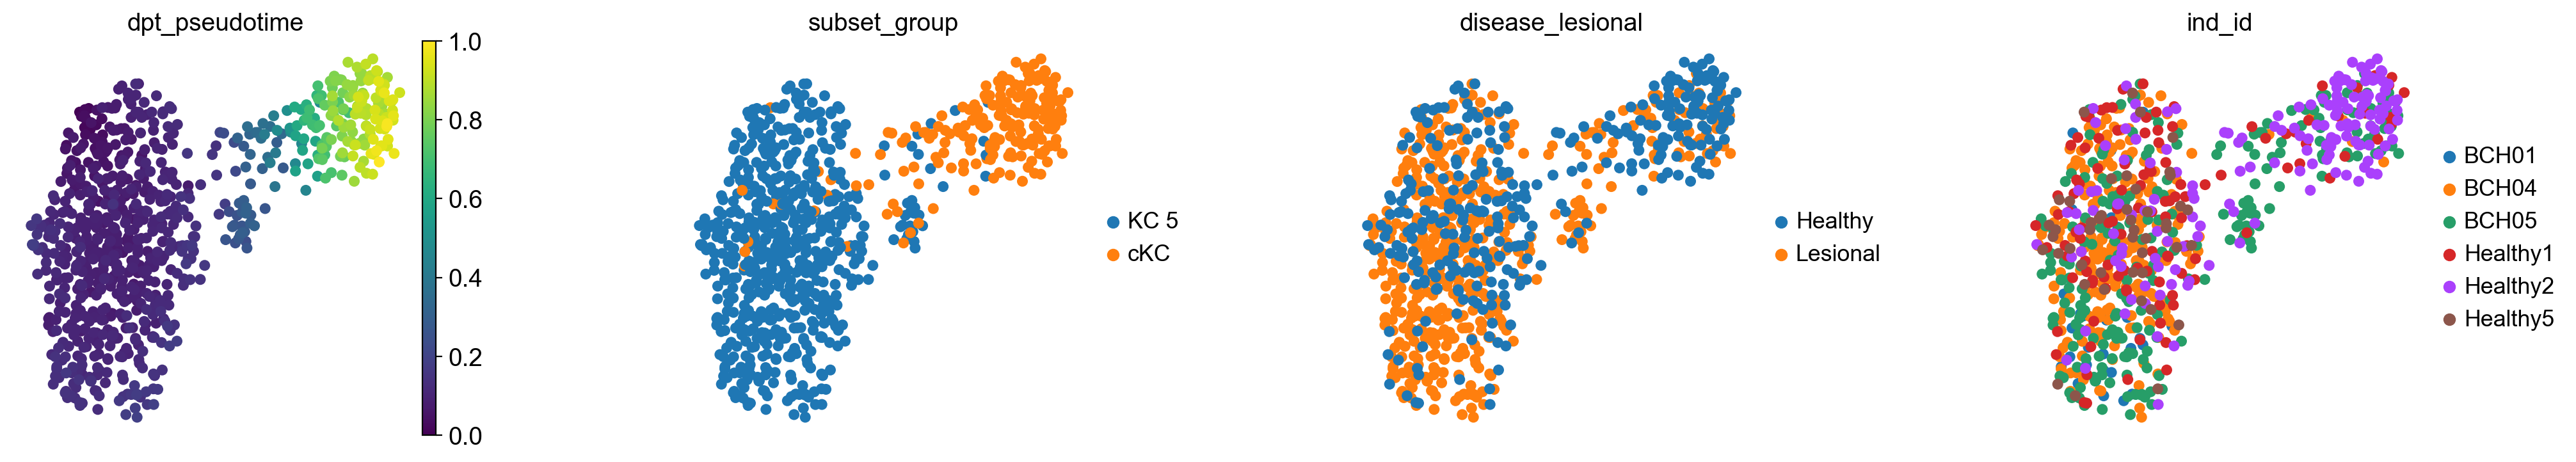

       dpt_pseudotime
count      798.000000
mean         0.251986
std          0.286953
min          0.000000
25%          0.090488
50%          0.109333
75%          0.233194
max          1.000000

Pseudotime range: 0.000 to 1.000


In [83]:
# --- Diffusion map ---
sc.tl.diffmap(kera)

# setting root
kera.uns['iroot'] = np.argmax(kera.obsm['X_umap'][:, 1]*(-kera.obsm['X_umap'][:, 0])) # authors method of choosing root

# --- DPT pseudotime ---
sc.tl.dpt(kera)

# --- Visualize ---
sc.pl.umap(kera, 
           color=['dpt_pseudotime', 'subset_group', 'disease_lesional', 'ind_id'],
           cmap='viridis',
           wspace=0.5, 
           frameon=False)

# --- Pseudotime distribution by condition ---
print(kera.obs[['dpt_pseudotime', 'subset_group', 'disease_lesional']].describe())
print(f"\nPseudotime range: {kera.obs['dpt_pseudotime'].min():.3f} to {kera.obs['dpt_pseudotime'].max():.3f}")

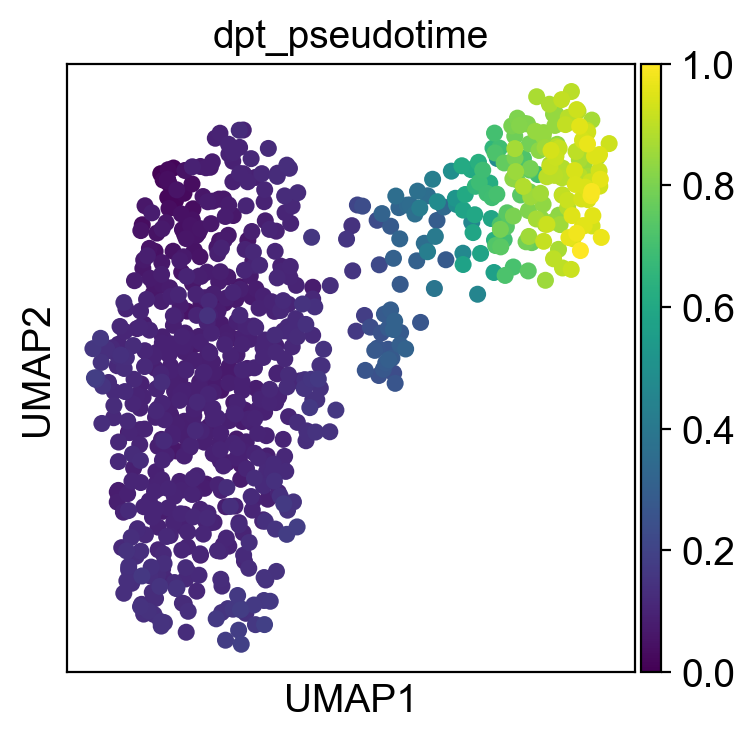

In [82]:
sc.pl.umap(kera, color='dpt_pseudotime')

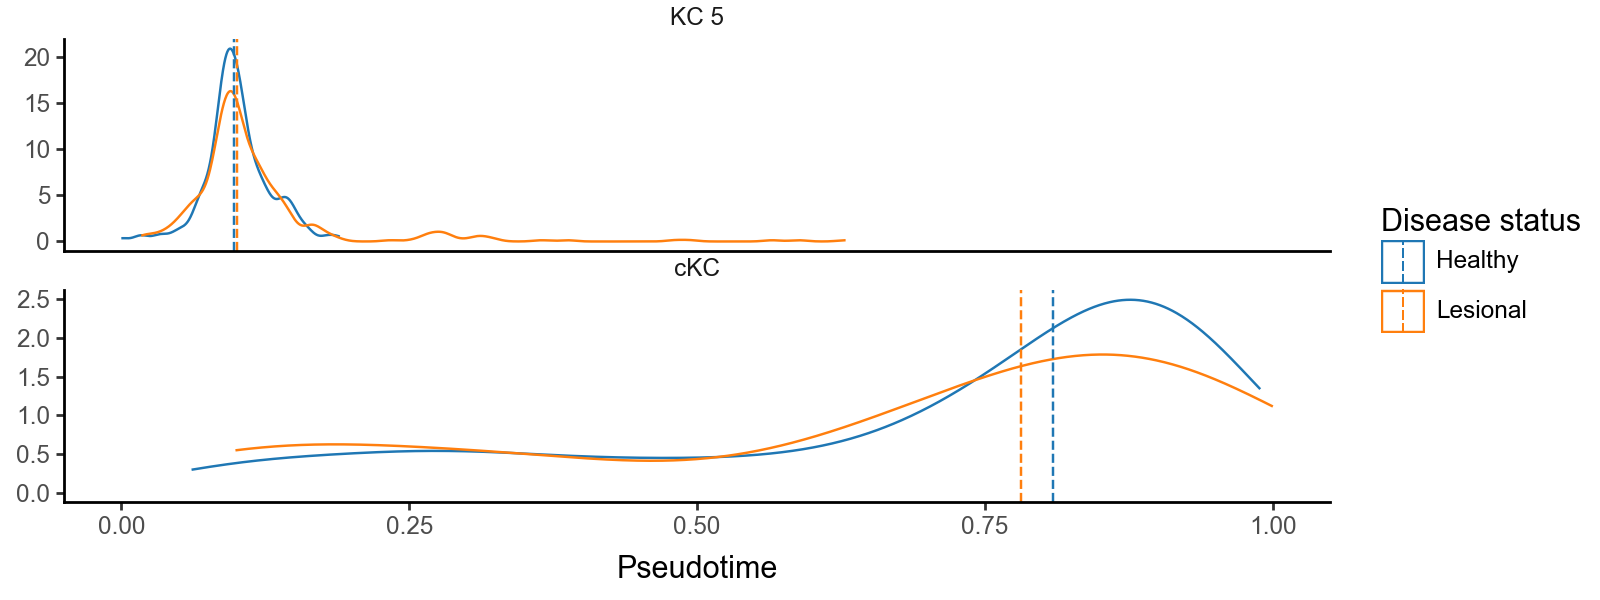

In [87]:
df = kera.obs[['dpt_pseudotime', 'disease_lesional', 'subset_group']]
df['dpt_rank'] = np.argsort(np.argsort(df.dpt_pseudotime)).astype(float)

import plotnine as p9

f = (p9.ggplot(p9.aes(x='dpt_pseudotime', color='disease_lesional'), df) + 
    #p9.geom_point(size=0.1) + 
    #p9.geom_smooth(method='loess', color='#555555', se=False) +
    #p9.geom_path() + 
    #p9.geom_rug() +
    p9.geom_density(trim=True) +
    p9.geom_vline(p9.aes(xintercept='dpt_pseudotime', color='disease_lesional'), linetype='dashed', data=df.groupby(['disease_lesional', 'subset_group']).median().reset_index()) +
    p9.theme_classic() + 
    p9.facet_wrap('subset_group', scales='free_y', ncol=1) + 
    p9.theme(figure_size=(8,3), panel_spacing_x=0.5, text=p9.element_text(family='Arial'), strip_background=p9.element_blank()) + 
    p9.labs(x='Pseudotime', y='', color='Disease status') +
    p9.scale_x_continuous(limits=[0, 1]) +
    p9.scale_color_manual(velo.uns['disease_lesional_colors'])     
)

f

In [95]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd

# Mirroring the stat testing authors ran (with some cleaned up output formatting and added BH correction) 
# dropped the exploratory ks_2samp test from authors run as well


# HEALTHY vs LESIONAL (no non_lesional samples used in my reproduction run)
res = []

for ct in df['subset_group'].cat.categories:
    x = df[(df.disease_lesional == 'Healthy')  & (df['subset_group'] == ct)].dpt_pseudotime
    y = df[(df.disease_lesional == 'Lesional') & (df['subset_group'] == ct)].dpt_pseudotime
    
    if len(x) == 0 or len(y) == 0:
        continue
    
    mwu = mannwhitneyu(x, y, alternative='two-sided')
    
    res.append({
        'comparison'      : 'Healthy vs Lesional',
        'subset_group'    : ct,
        'n_healthy'       : len(x),
        'n_lesional'      : len(y),
        'median_healthy'  : round(x.median(), 4),
        'median_lesional' : round(y.median(), 4),
        'mwu_stat'        : round(mwu.statistic, 4),
        'mwu_pval'        : mwu.pvalue
    })

res_df = pd.DataFrame(res)

# BH correction across cell types
res_df['mwu_padj'] = multipletests(res_df['mwu_pval'], method='fdr_bh')[1]

# Format p-values
for col in ['mwu_pval', 'mwu_padj']:
    res_df[col] = res_df[col].map('{:.2e}'.format)

print("=== Pseudotime Distribution: Healthy vs Lesional (Mann-Whitney U) ===\n")
print(res_df.to_string(index=False))

res_df.to_csv("pseudotime_HvsL_mannwhitneyu.tsv", sep='\t', index=False)

=== Pseudotime Distribution: Healthy vs Lesional (Mann-Whitney U) ===

         comparison subset_group  n_healthy  n_lesional  median_healthy  median_lesional  mwu_stat mwu_pval mwu_padj
Healthy vs Lesional         KC 5        193         411          0.0978           0.1007   37125.0 2.05e-01 4.10e-01
Healthy vs Lesional          cKC        132          62          0.8095           0.7816    4371.0 4.45e-01 4.45e-01


### Discussion:
Authors report statistical significance in their run with ~3200 cells, but I fail to reproduce with 798 cells. The pseudotime trajectories seems to atleast trend consistently with the authors report.

Authors don't report their per disease-status cell counts or apply any FDR detection. 

*Due to the lower number of cells in my run, its probably more appropriate calculating and using the dpt_pseudotime using BKNNN as in the pseudotime_testing notebook instead. 

### Authors plot and stats for reference: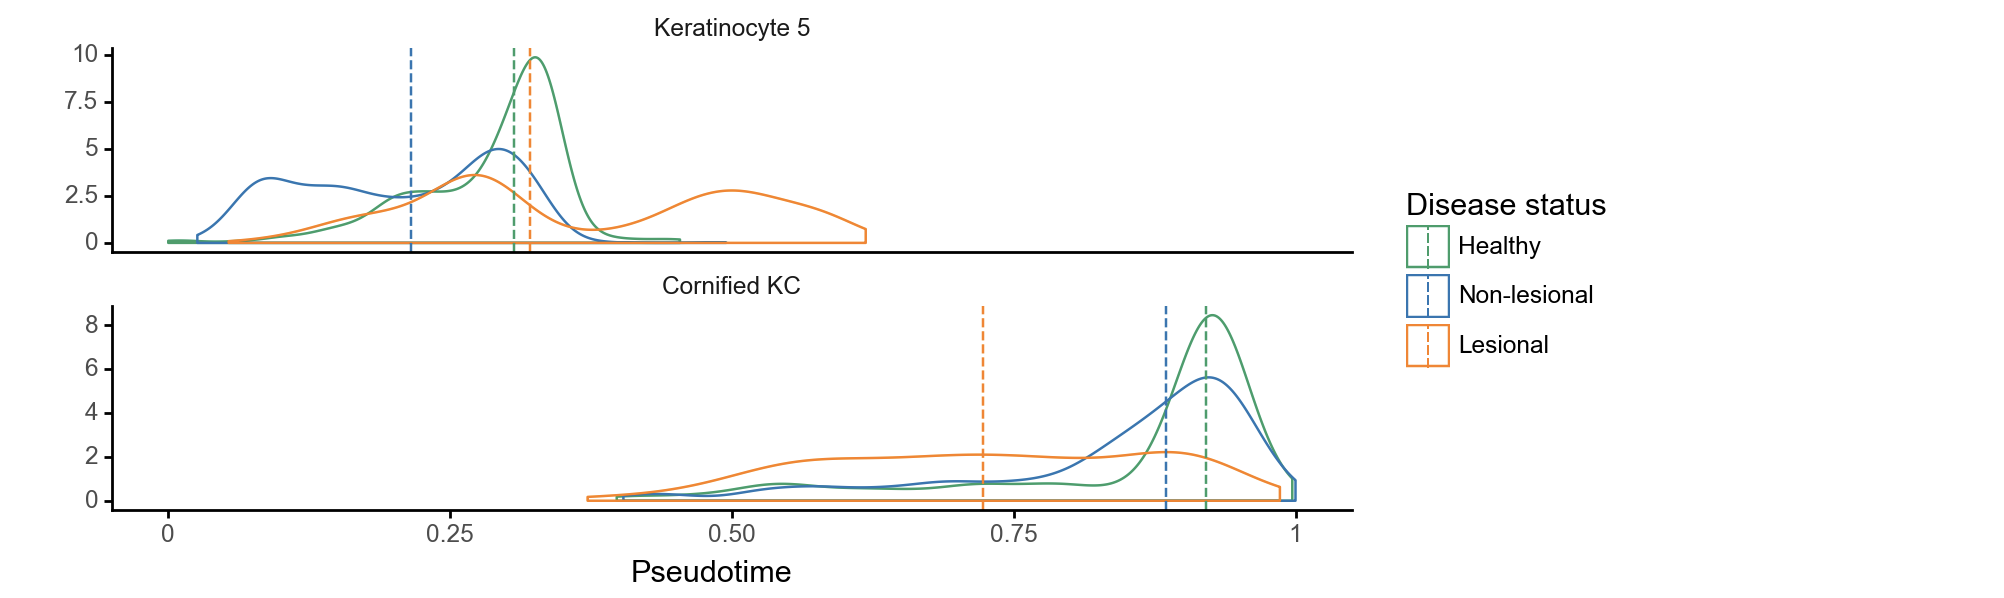